# Project 04 — 강력 편입 예상 종목 투자 수익률 분석

## 분석 개요
- **목적**: 모델이 예측한 **강력 편입** 종목을 편입 발표 직후 매수했을 때의 수익률 검증
- **강력 편입 정의**: `전기 비구성원(prev_member=0)` + `예측 TOP200 진입(pred_top200=1)`
- **매수 시점**: KOSPI200 편입 발표 기준일 이후 첫 거래일 종가
  - H1(상반기): 4/30 기준 → 5/1 이후 첫 거래일 종가
  - H2(하반기): 10/31 기준 → 11/1 이후 첫 거래일 종가
- **매도 시점**: 실제 지수 변경 적용일 (6월/12월 둘째 주 금요일, 휴장 시 전날)
- **벤치마크**: 동일 기간 KOSPI200 기존 구성종목 평균 수익률

## 1. 환경 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

print('환경 설정 완료')

환경 설정 완료


## 2. 데이터 로드

In [2]:
# 일별 주가 데이터 (daily_raw.parquet)
daily = pd.read_parquet('daily_raw.parquet')
daily['date'] = pd.to_datetime(daily['date'])

# KOSPI200 예측 결과
h1_pred = pd.read_csv('kospi200_prediction_2025_H1.csv', dtype={'ticker': str})
h2_pred = pd.read_csv('kospi200_prediction_2025_H2.csv', dtype={'ticker': str})

print(f'일별 주가 데이터: {daily.shape}  ({daily["date"].min().date()} ~ {daily["date"].max().date()})')
print(f'H1 예측 종목 수: {len(h1_pred)}')
print(f'H2 예측 종목 수: {len(h2_pred)}')

일별 주가 데이터: (438024, 7)  (2019-05-02 ~ 2025-10-31)
H1 예측 종목 수: 274
H2 예측 종목 수: 275


## 3. 라벨 검증 — project_03 성능 지표 신뢰성 확인

> **배경**: `kospi200_prediction_2025_H1/H2.csv` 파일의 `실제편입`/`실제편출` 컬럼이
> 실제 KOSPI200 목록과 다른 것을 발견.
> project_03.ipynb가 **DB `labels` 테이블**을 직접 참조했는지 확인하여
> 성능 지표(44.0% 등)가 올바른 라벨 기준으로 계산됐는지 검증한다.


In [3]:
import mysql.connector

DB_CFG = {'host':'localhost','user':'root','password':'1234','database':'kospi_db'}

# ── DB labels 테이블 로드 ───────────────────────────────────────────────────
conn = mysql.connector.connect(**DB_CFG)
labels_db = pd.read_sql('SELECT * FROM labels', conn)
conn.close()

# ── 실제 KOSPI200 목록 파일 기준 정답 계산 ─────────────────────────────────
DATA_PATH = 'data'

def norm(code_str):
    """종목코드 앞 0 제거 통일 (005930 → 5930)"""
    return str(int(code_str)) if str(code_str).isdigit() else code_str.lstrip('0')

def load_kospi_list(filename):
    df = pd.read_csv(f'{DATA_PATH}/{filename}', dtype=str, encoding='cp949')
    return set(df['종목코드'].apply(norm))

set_2024h2 = load_kospi_list('KOSPI200_list_20241216.csv')  # H1 이전 기준
set_2025h1 = load_kospi_list('KOSPI200_list_20250616.csv')  # H1 실제 목록
set_2025h2 = load_kospi_list('KOSPI200_list_20251215.csv')  # H2 실제 목록

actual_in_h1  = set_2025h1 - set_2024h2   # 실제 H1 편입
actual_out_h1 = set_2024h2 - set_2025h1   # 실제 H1 편출
actual_in_h2  = set_2025h2 - set_2025h1   # 실제 H2 편입
actual_out_h2 = set_2025h1 - set_2025h2   # 실제 H2 편출

# ── DB labels vs 실제 목록 비교 ────────────────────────────────────────────
db_h1_in  = set(labels_db[(labels_db['period']=='2025_H1') & (labels_db['label_in']==1)]['ticker'])
db_h1_out = set(labels_db[(labels_db['period']=='2025_H1') & (labels_db['label_out']==1)]['ticker'])
db_h2_in  = set(labels_db[(labels_db['period']=='2025_H2') & (labels_db['label_in']==1)]['ticker'])
db_h2_out = set(labels_db[(labels_db['period']=='2025_H2') & (labels_db['label_out']==1)]['ticker'])

print('=== DB labels 테이블 vs 실제 KOSPI200 목록 일치 여부 ===')
print(f'  H1 편입 일치: {db_h1_in == actual_in_h1}   DB={sorted(db_h1_in)}')
print(f'  H1 편출 일치: {db_h1_out == actual_out_h1}  DB={sorted(db_h1_out)}')
print(f'  H2 편입 일치: {db_h2_in == actual_in_h2}   DB={sorted(db_h2_in)}')
print(f'  H2 편출 일치: {db_h2_out == actual_out_h2}  DB={sorted(db_h2_out)}')
print()

# ── CSV 실제편입 vs 실제 목록 비교 ─────────────────────────────────────────
csv_h1_in  = set(h1_pred[h1_pred['실제편입']==1]['ticker'])
csv_h2_in  = set(h2_pred[h2_pred['실제편입']==1]['ticker'])

print('=== CSV 파일 실제편입 vs 실제 KOSPI200 목록 ===')
print(f'  H1 CSV 실제편입: {sorted(csv_h1_in)}')
print(f'  H1 실제 편입:    {sorted(actual_in_h1)}')
print(f'  H1 일치: {csv_h1_in == actual_in_h1}  ← CSV가 잘못됨' if csv_h1_in != actual_in_h1 else '  H1 일치: True')
print()
print(f'  H2 CSV 실제편입: {sorted(csv_h2_in)}')
print(f'  H2 실제 편입:    {sorted(actual_in_h2)}')
print(f'  H2 일치: {csv_h2_in == actual_in_h2}  ← CSV가 잘못됨' if csv_h2_in != actual_in_h2 else '  H2 일치: True')
print()

print('─' * 60)
print('✅ DB labels 테이블 = 실제 KOSPI200 목록 (project_03 성능 지표는 정확)')
print('❌ CSV 파일 실제편입 컬럼 = 잘못된 라벨 (CSV만 수정 필요)')


=== DB labels 테이블 vs 실제 KOSPI200 목록 일치 여부 ===
  H1 편입 일치: True   DB=['12630', '17960', '268280', '3240', '443060', '6040', '670', '71320', '7340']
  H1 편출 일치: True  DB=['105630', '1120', '1570', '1740', '178920', '271940', '336260', '5070', '6110']
  H2 편입 일치: True   DB=['126Z0', '2030', '307950', '34230', '62040', '64400', '7660', '82740']
  H2 편출 일치: True  DB=['10620', '12630', '145720', '2710', '3620', '39130', '456040', '489790']

=== CSV 파일 실제편입 vs 실제 KOSPI200 목록 ===
  H1 CSV 실제편입: ['278470', '2840', '298040', '456040']
  H1 실제 편입:    ['12630', '17960', '268280', '3240', '443060', '6040', '670', '71320', '7340']
  H1 일치: False  ← CSV가 잘못됨

  H2 CSV 실제편입: ['12630', '17960', '268280', '3240', '443060', '6040', '670', '71320', '7340']
  H2 실제 편입:    ['126Z0', '2030', '307950', '34230', '62040', '64400', '7660', '82740']
  H2 일치: False  ← CSV가 잘못됨

────────────────────────────────────────────────────────────
✅ DB labels 테이블 = 실제 KOSPI200 목록 (project_03 성능 지표는 정확)
❌ CSV 파일 실제편입 컬럼 = 잘못

### 3-1. CSV 실제편입/편출 컬럼 수정

DB `labels` 기준으로 예측 CSV 파일의 `실제편입`/`실제편출` 컬럼을 올바른 값으로 덮어씁니다.
이후 분석은 수정된 DataFrame을 기준으로 진행합니다.


In [4]:
def apply_correct_labels(pred_df, labels_db, period):
    """
    DB labels 기준으로 실제편입/실제편출/실제멤버 컬럼을 수정한 DataFrame 반환
    """
    df = pred_df.copy()
    lp = labels_db[labels_db['period'] == period][['ticker','label_in','label_out','is_member']].copy()
    lp = lp.rename(columns={'label_in':'실제편입_fix','label_out':'실제편출_fix','is_member':'실제멤버_fix'})

    df = df.merge(lp, on='ticker', how='left')

    # 수정 전후 비교 출력
    changed_in = df[df['실제편입'] != df['실제편입_fix'].fillna(0).astype(int)]
    if len(changed_in) > 0:
        print(f'[{period}] 실제편입 수정: {len(changed_in)}개 종목')
        print(changed_in[['ticker','company','실제편입','실제편입_fix']].to_string(index=False))
        print()

    df['실제편입'] = df['실제편입_fix'].fillna(0).astype(int)
    df['실제편출'] = df['실제편출_fix'].fillna(0).astype(int)
    df['실제멤버'] = df['실제멤버_fix'].fillna(0).astype(int)
    return df.drop(columns=['실제편입_fix','실제편출_fix','실제멤버_fix'])

h1_pred = apply_correct_labels(h1_pred, labels_db, '2025_H1')
h2_pred = apply_correct_labels(h2_pred, labels_db, '2025_H2')

print('=== 수정 후 H1 강력편입 중 실제편입 ===')
print(h1_pred[h1_pred['강력편입']==1][['ticker','company','실제편입']].to_string(index=False))
print()
print('=== 수정 후 H2 강력편입 중 실제편입 ===')
print(h2_pred[h2_pred['강력편입']==1][['ticker','company','실제편입']].to_string(index=False))


[2025_H1] 실제편입 수정: 12개 종목
ticker company  실제편입  실제편입_fix
298040   효성중공업     1       0.0
278470    에이피알     1       0.0
  2840    미원상사     1       0.0
  6040    동원산업     0       1.0
  7340 DN오토모티브     0       1.0
  3240    태광산업     0       1.0
   670      영풍     0       1.0
 12630     HDC     0       1.0
 17960    한국카본     0       1.0
456040     OCI     1       0.0
268280   미원에스씨     0       1.0
 71320  지역난방공사     0       1.0

[2025_H2] 실제편입 수정: 15개 종목
ticker   company  실제편입  실제편입_fix
443060 HD현대마린솔루션     1       0.0
 82740      한화엔진     0       1.0
  7660    이수페타시스     0       1.0
 34230     파라다이스     0       1.0
   670        영풍     1       0.0
 62040      산일전기     0       1.0
  3240      태광산업     1       0.0
 12630       HDC     1       0.0
  6040      동원산업     1       0.0
 17960      한국카본     1       0.0
  7340   DN오토모티브     1       0.0
307950    현대오토에버     0       1.0
 71320    지역난방공사     1       0.0
268280     미원에스씨     1       0.0
  2030       아세아     0       1.0

=== 수정 후 H1 강력편

### 3-2. 수정된 CSV 저장

검증 완료된 올바른 라벨로 CSV 파일을 덮어씁니다.


In [5]:
# CSV 저장은 별도 실행 (파일 잠금 방지)
# h1_pred.to_csv('kospi200_prediction_2025_H1.csv', index=False, encoding='utf-8-sig')
# h2_pred.to_csv('kospi200_prediction_2025_H2.csv', index=False, encoding='utf-8-sig')
# print('CSV 파일 저장 완료 (실제편입/실제편출 컬럼 수정됨)')
# print('  kospi200_prediction_2025_H1.csv')
# print('  kospi200_prediction_2025_H2.csv')
# 

## 3. 날짜 계산 유틸리티

- **매수일**: 기준일(4/30 또는 10/31) 이후 첫 거래일
- **매도일**: 6월 또는 12월의 두 번째 금요일 (휴장 시 전날)

In [6]:
def get_trading_days(daily_df):
    """전체 거래일 목록 반환"""
    return pd.DatetimeIndex(sorted(daily_df['date'].unique()))

def get_next_trading_day(target_date, trading_days):
    """target_date 이후(포함) 첫 거래일"""
    target = pd.Timestamp(target_date)
    valid = trading_days[trading_days >= target]
    return valid[0] if len(valid) > 0 else None

def get_prev_trading_day(target_date, trading_days):
    """target_date 이전(포함) 마지막 거래일 (휴장 시 전날 처리)"""
    target = pd.Timestamp(target_date)
    valid = trading_days[trading_days <= target]
    return valid[-1] if len(valid) > 0 else None

def get_second_friday(year, month, trading_days):
    """
    해당 연월의 두 번째 금요일 반환 (휴장이면 그 전 거래일)
    weekday: 0=월, 1=화, 2=수, 3=목, 4=금
    """
    first_day = pd.Timestamp(year, month, 1)
    days_to_friday = (4 - first_day.weekday()) % 7  # 첫 금요일까지 일수
    first_friday = first_day + pd.Timedelta(days=days_to_friday)
    second_friday = first_friday + pd.Timedelta(weeks=1)
    return get_prev_trading_day(second_friday, trading_days)

trading_days = get_trading_days(daily)

# H1 날짜 계산
h1_buy_date  = get_next_trading_day('2025-05-01', trading_days)  # 5/1 이후 첫 거래일
h1_sell_date = get_second_friday(2025, 6, trading_days)          # 6월 둘째주 금요일

# H2 날짜 계산
h2_buy_date  = get_next_trading_day('2025-11-01', trading_days)  # 11/1 이후 첫 거래일
h2_sell_date = get_second_friday(2025, 12, trading_days)         # 12월 둘째주 금요일

print('=== H1 (2025 상반기) ===')
print(f'  매수일: {h1_buy_date.date() if h1_buy_date else "데이터 없음"}')
print(f'  매도일: {h1_sell_date.date() if h1_sell_date else "데이터 없음"}')
print()
print('=== H2 (2025 하반기) ===')
print(f'  매수일: {h2_buy_date.date() if h2_buy_date else "데이터 없음 (11월 이후 데이터 필요)"}')
print(f'  매도일: {h2_sell_date.date() if h2_sell_date else "데이터 없음 (12월 이후 데이터 필요)"}')

=== H1 (2025 상반기) ===
  매수일: 2025-05-02
  매도일: 2025-06-13

=== H2 (2025 하반기) ===
  매수일: 데이터 없음 (11월 이후 데이터 필요)
  매도일: 2025-10-31


## 4. 수익률 계산 함수

In [7]:
def calc_returns(pred_df, buy_date, sell_date, daily_df, label=''):
    """
    강력 편입 종목의 수익률 계산
    
    Parameters:
        pred_df   : 예측 결과 DataFrame (강력편입 컬럼 포함)
        buy_date  : 매수일 (Timestamp)
        sell_date : 매도일 (Timestamp)
        daily_df  : 일별 주가 DataFrame
        label     : 반기 레이블 ('H1', 'H2')
    
    Returns:
        result    : 강력 편입 종목별 수익률 DataFrame
        benchmark : KOSPI200 기존 구성원 평균 수익률 (float)
    """
    if buy_date is None or sell_date is None:
        print(f'[{label}] 해당 기간 주가 데이터 없음 (daily_raw 업데이트 필요)')
        return None, None

    # ── 강력 편입 종목 ──────────────────────────────────────────
    strong = pred_df[pred_df['강력편입'] == 1].copy()

    buy_prices  = daily_df[daily_df['date'] == buy_date][['ticker','종가']].rename(columns={'종가':'매수가'})
    sell_prices = daily_df[daily_df['date'] == sell_date][['ticker','종가']].rename(columns={'종가':'매도가'})

    result = (
        strong[['ticker','company','score','pred_rank','실제편입']]
        .astype({'ticker': str})
        .merge(buy_prices,  on='ticker', how='left')
        .merge(sell_prices, on='ticker', how='left')
    )
    result['수익률(%)'] = (result['매도가'] - result['매수가']) / result['매수가'] * 100
    result['보유기간'] = f"{buy_date.date()} ~ {sell_date.date()}"
    result['half'] = label

    # ── 벤치마크: 전기 구성원 (기존 KOSPI200) ──────────────────
    members = pred_df[pred_df['prev_member'] == 1]['ticker'].astype(str).tolist()
    bm_buy  = daily_df[daily_df['date'] == buy_date][['ticker','종가']].rename(columns={'종가':'매수가'})
    bm_sell = daily_df[daily_df['date'] == sell_date][['ticker','종가']].rename(columns={'종가':'매도가'})
    bm = pd.DataFrame({'ticker': members}).merge(bm_buy, on='ticker').merge(bm_sell, on='ticker')
    bm['수익률(%)'] = (bm['매도가'] - bm['매수가']) / bm['매수가'] * 100
    benchmark = bm['수익률(%)'].mean()

    return result, benchmark

## 5. H1 (2025 상반기) 수익률 분석

- 매수: **2025-05-02** (5/1 근로자의 날 공휴일 → 다음 거래일)
- 매도: **2025-06-13** (6월 둘째 주 금요일, KOSPI200 지수 변경 적용일)

In [8]:
h1_result, h1_benchmark = calc_returns(h1_pred, h1_buy_date, h1_sell_date, daily, label='H1')

if h1_result is not None:
    h1_valid = h1_result.dropna(subset=['수익률(%)'])

    print(f'=== H1 강력 편입 종목 수익률 ({h1_buy_date.date()} → {h1_sell_date.date()}) ===')
    print()

    display_cols = ['ticker','company','score','pred_rank','매수가','매도가','수익률(%)','실제편입']
    h1_show = h1_result[display_cols].copy().sort_values('수익률(%)', ascending=False).reset_index(drop=True)

    # 포매팅
    h1_show_fmt = h1_show.copy()
    h1_show_fmt['score'] = h1_show_fmt['score'].map('{:.4f}'.format)
    h1_show_fmt['매수가'] = h1_show_fmt['매수가'].map(lambda x: f'{int(x):,}' if pd.notna(x) else 'N/A')
    h1_show_fmt['매도가'] = h1_show_fmt['매도가'].map(lambda x: f'{int(x):,}' if pd.notna(x) else 'N/A')
    h1_show_fmt['수익률(%)'] = h1_show['수익률(%)'].map(lambda x: f'{x:+.2f}%' if pd.notna(x) else 'N/A')
    h1_show_fmt['실제편입'] = h1_show_fmt['실제편입'].map(lambda x: '✓ 편입' if x == 1 else '✗ 미편입')
    print(h1_show_fmt.to_string(index=True))

    print()
    print('─' * 55)
    print(f'  강력 편입 종목 평균 수익률  : {h1_valid["수익률(%)"].mean():+.2f}%  (n={len(h1_valid)})')
    print(f'  ├ 실제 편입 종목 평균       : {h1_valid[h1_valid["실제편입"]==1]["수익률(%)"].mean():+.2f}%  (n={int(h1_valid["실제편입"].sum())})')
    print(f'  └ 미편입 종목 평균          : {h1_valid[h1_valid["실제편입"]==0]["수익률(%)"].mean():+.2f}%  (n={(h1_valid["실제편입"]==0).sum()})')
    print(f'  KOSPI200 기존 구성원 평균   : {h1_benchmark:+.2f}%  (벤치마크)')
    print(f'  초과 수익률 (강력편입 - BM) : {h1_valid["수익률(%)"].mean() - h1_benchmark:+.2f}%p')

=== H1 강력 편입 종목 수익률 (2025-05-02 → 2025-06-13) ===

    ticker    company   score  pred_rank      매수가      매도가   수익률(%)   실제편입
0   278470       에이피알  0.9963        115   76,200  131,000  +71.92%  ✗ 미편입
1   100090    SK오션플랜트  0.8286        179   14,420   20,350  +41.12%  ✗ 미편입
2   298040      효성중공업  0.9995         84  507,000  680,000  +34.12%  ✗ 미편입
3   192400      쿠쿠홀딩스  0.1696        200   24,250   30,800  +27.01%  ✗ 미편입
4    89860       롯데렌탈  0.1764        199   29,450   33,600  +14.09%  ✗ 미편입
5     6040       동원산업  0.2145        198   41,750   46,300  +10.90%   ✓ 편입
6    82740       한화엔진  0.7368        183   27,750   29,350   +5.77%  ✗ 미편입
7   229640    LS에코에너지  0.7900        180   32,250   34,100   +5.74%  ✗ 미편입
8    88980     맥쿼리인프라  0.5618        189   11,590   11,710   +1.04%  ✗ 미편입
9   267270     HD건설기계  0.2306        196   69,100   69,300   +0.29%  ✗ 미편입
10    3850         보령  0.7647        181    8,520    8,510   -0.12%  ✗ 미편입
11  294870  HDC현대산업개발  0.8911        175   25,400

## 6. H1 수익률 시각화

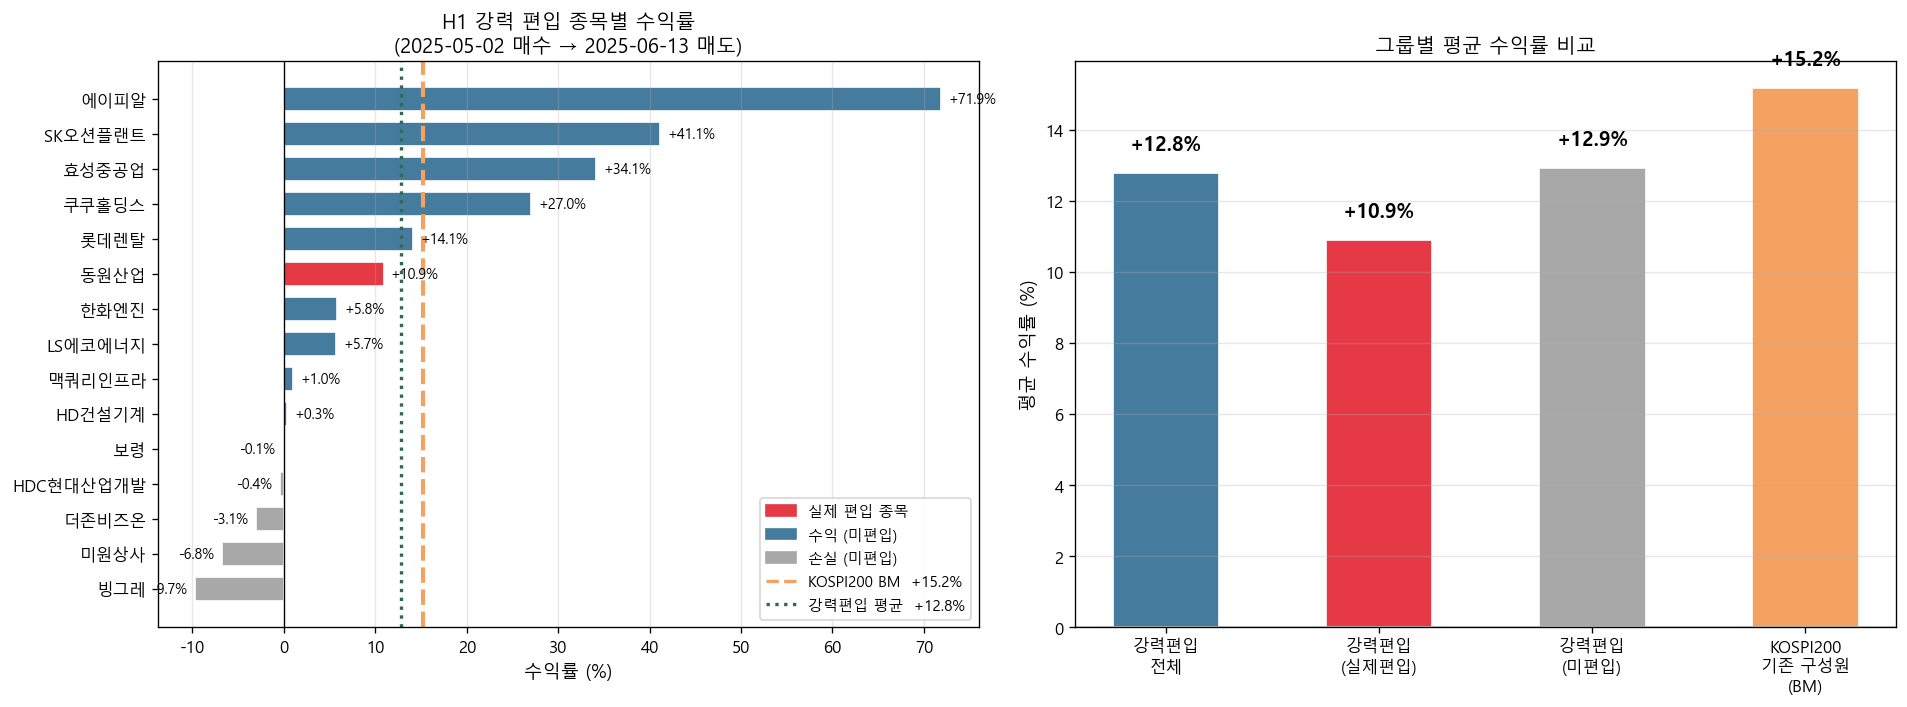

그래프 저장: h1_return_analysis.png


In [9]:
if h1_result is not None:
    h1_valid = h1_result.dropna(subset=['수익률(%)'])
    h1_sorted = h1_valid.sort_values('수익률(%)', ascending=True).reset_index(drop=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # ── 종목별 수익률 막대그래프 ──────────────────────────────────
    ax = axes[0]
    bar_colors = []
    for _, row in h1_sorted.iterrows():
        if row['실제편입'] == 1:
            bar_colors.append('#E63946')   # 실제편입: 빨강
        elif row['수익률(%)'] >= 0:
            bar_colors.append('#457B9D')   # 수익: 파랑
        else:
            bar_colors.append('#A8A8A8')   # 손실: 회색

    bars = ax.barh(h1_sorted['company'], h1_sorted['수익률(%)'],
                   color=bar_colors, edgecolor='white', height=0.7)
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.axvline(x=h1_benchmark, color='#F4A261', linewidth=2.5, linestyle='--',
               label=f'KOSPI200 BM  {h1_benchmark:+.1f}%')
    ax.axvline(x=h1_valid['수익률(%)'].mean(), color='#2D6A4F', linewidth=2, linestyle=':',
               label=f'강력편입 평균  {h1_valid["수익률(%)"].mean():+.1f}%')

    for bar, val in zip(bars, h1_sorted['수익률(%)']):
        x_pos = val + 0.8 if val >= 0 else val - 0.8
        ha = 'left' if val >= 0 else 'right'
        ax.text(x_pos, bar.get_y() + bar.get_height()/2,
                f'{val:+.1f}%', va='center', ha=ha, fontsize=8.5)

    legend_handles = [
        mpatches.Patch(color='#E63946', label='실제 편입 종목'),
        mpatches.Patch(color='#457B9D', label='수익 (미편입)'),
        mpatches.Patch(color='#A8A8A8', label='손실 (미편입)'),
        plt.Line2D([0],[0], color='#F4A261', linestyle='--', linewidth=2,
                   label=f'KOSPI200 BM  {h1_benchmark:+.1f}%'),
        plt.Line2D([0],[0], color='#2D6A4F', linestyle=':', linewidth=2,
                   label=f'강력편입 평균  {h1_valid["수익률(%)"].mean():+.1f}%'),
    ]
    ax.legend(handles=legend_handles, loc='lower right', fontsize=9)
    ax.set_xlabel('수익률 (%)', fontsize=11)
    ax.set_title(f'H1 강력 편입 종목별 수익률\n({h1_buy_date.date()} 매수 → {h1_sell_date.date()} 매도)',
                 fontsize=12)
    ax.grid(axis='x', alpha=0.3)

    # ── 그룹별 평균 수익률 비교 막대그래프 ───────────────────────
    ax2 = axes[1]
    group_labels = ['강력편입\n전체', '강력편입\n(실제편입)', '강력편입\n(미편입)', 'KOSPI200\n기존 구성원\n(BM)']
    group_values = [
        h1_valid['수익률(%)'].mean(),
        h1_valid[h1_valid['실제편입']==1]['수익률(%)'].mean(),
        h1_valid[h1_valid['실제편입']==0]['수익률(%)'].mean(),
        h1_benchmark,
    ]
    g_colors = ['#457B9D', '#E63946', '#A8A8A8', '#F4A261']
    bars2 = ax2.bar(group_labels, group_values, color=g_colors, edgecolor='white', width=0.5)
    ax2.axhline(y=0, color='black', linewidth=0.8)

    for bar, val in zip(bars2, group_values):
        if pd.notna(val):
            y_pos = val + 0.5 if val >= 0 else val - 0.5
            va = 'bottom' if val >= 0 else 'top'
            ax2.text(bar.get_x() + bar.get_width()/2, y_pos, f'{val:+.1f}%',
                     ha='center', va=va, fontsize=12, fontweight='bold')

    ax2.set_ylabel('평균 수익률 (%)', fontsize=11)
    ax2.set_title('그룹별 평균 수익률 비교', fontsize=12)
    ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('h1_return_analysis.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('그래프 저장: h1_return_analysis.png')

## 7. H2 (2025 하반기) 수익률 분석

- 매수 예정: **2025-11-03** (11/1 이후 첫 거래일)
- 매도 예정: **2025-12-12** (12월 둘째 주 금요일)

> ⚠️ **데이터 범위 제한**: `daily_raw.parquet`의 최신 데이터가 2025-10-31까지이므로 H2 수익률은 아직 계산 불가  
> `datapipeline.py`로 데이터 업데이트 후 아래 셀을 다시 실행하면 자동 계산됩니다.

In [10]:
h2_result, h2_benchmark = calc_returns(h2_pred, h2_buy_date, h2_sell_date, daily, label='H2')

if h2_result is not None:
    h2_valid = h2_result.dropna(subset=['수익률(%)'])
    print(f'=== H2 강력 편입 종목 수익률 ({h2_buy_date.date()} → {h2_sell_date.date()}) ===')
    display_cols = ['ticker','company','score','pred_rank','매수가','매도가','수익률(%)','실제편입']
    h2_show = h2_result[display_cols].copy().sort_values('수익률(%)', ascending=False).reset_index(drop=True)
    h2_show['수익률(%)'] = h2_show['수익률(%)'].map(lambda x: f'{x:+.2f}%' if pd.notna(x) else 'N/A')
    print(h2_show.to_string())
    print()
    print(f'  강력 편입 종목 평균 수익률 : {h2_valid["수익률(%)"].mean():+.2f}%')
    print(f'  KOSPI200 기존 구성원 평균  : {h2_benchmark:+.2f}%  (벤치마크)')
else:
    print('H2 매수일 이후 데이터가 아직 없습니다.')
    print(f'  예정 매수일: {h2_buy_date.date() if h2_buy_date else "없음 (데이터 필요)"}')
    print(f'  예정 매도일: {h2_sell_date.date() if h2_sell_date else "없음 (데이터 필요)"}')
    print()
    print('H2 강력 편입 예상 종목 (수익률 추후 업데이트):')
    h2_strong = h2_pred[h2_pred['강력편입']==1][['ticker','company','score','pred_rank','실제편입']].reset_index(drop=True)
    print(h2_strong.to_string())

[H2] 해당 기간 주가 데이터 없음 (daily_raw 업데이트 필요)
H2 매수일 이후 데이터가 아직 없습니다.
  예정 매수일: 없음 (데이터 필요)
  예정 매도일: 2025-10-31

H2 강력 편입 예상 종목 (수익률 추후 업데이트):
    ticker    company     score  pred_rank  실제편입
0   443060  HD현대마린솔루션  0.999625         74     0
1    82740       한화엔진  0.993885        131     1
2     3570   SNT다이내믹스  0.990023        139     0
3     7660     이수페타시스  0.989364        141     1
4    34230      파라다이스  0.987030        145     1
5    12510      더존비즈온  0.979376        151     0
6      670         영풍  0.968193        161     0
7   294870  HDC현대산업개발  0.962018        162     0
8   462870       시프트업  0.945226        169     0
9    62040       산일전기  0.939740        172     1
10  192400      쿠쿠홀딩스  0.902035        178     0
11  267270     HD건설기계  0.878878        181     0
12    5180        빙그레  0.845963        184     0
13    3240       태광산업  0.838924        185     0
14   20560     아시아나항공  0.833241        186     0
15   71970   HD현대마린엔진  0.785662        188     0
16  100090    SK오션플랜트  0.754

## 8. 추가 분석 — 예측 점수(score)와 수익률 상관관계

모델의 예측 확률(score)이 높을수록 수익률도 높은지 확인합니다.

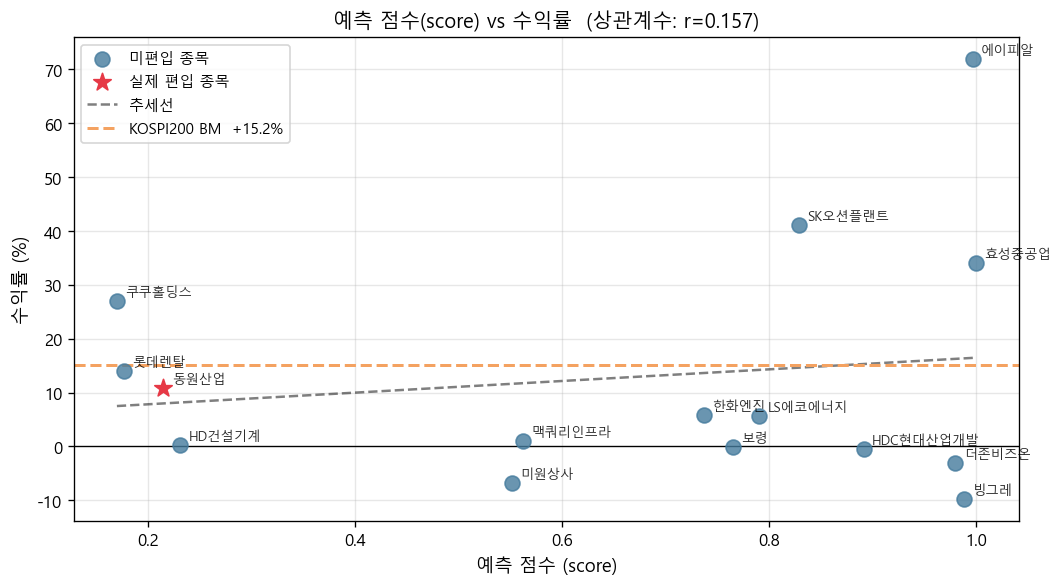

그래프 저장: h1_score_vs_return.png


In [11]:
if h1_result is not None:
    h1_valid = h1_result.dropna(subset=['수익률(%)'])

    fig, ax = plt.subplots(figsize=(9, 5))

    actual_mask = h1_valid['실제편입'] == 1
    ax.scatter(h1_valid[~actual_mask]['score'], h1_valid[~actual_mask]['수익률(%)'],
               color='#457B9D', s=80, alpha=0.8, label='미편입 종목', zorder=3)
    ax.scatter(h1_valid[actual_mask]['score'], h1_valid[actual_mask]['수익률(%)'],
               color='#E63946', s=120, marker='*', alpha=1.0, label='실제 편입 종목', zorder=4)

    for _, row in h1_valid.iterrows():
        ax.annotate(row['company'], (row['score'], row['수익률(%)']),
                    textcoords='offset points', xytext=(5, 3), fontsize=8, alpha=0.85)

    # 추세선
    if len(h1_valid) >= 3:
        z = np.polyfit(h1_valid['score'], h1_valid['수익률(%)'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(h1_valid['score'].min(), h1_valid['score'].max(), 100)
        ax.plot(x_line, p(x_line), 'k--', alpha=0.5, linewidth=1.5, label='추세선')
        corr = h1_valid['score'].corr(h1_valid['수익률(%)'])

    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.axhline(y=h1_benchmark, color='#F4A261', linestyle='--', linewidth=1.8,
               label=f'KOSPI200 BM  {h1_benchmark:+.1f}%')
    ax.set_xlabel('예측 점수 (score)', fontsize=11)
    ax.set_ylabel('수익률 (%)', fontsize=11)
    ax.set_title(f'예측 점수(score) vs 수익률  (상관계수: r={corr:.3f})', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('h1_score_vs_return.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('그래프 저장: h1_score_vs_return.png')

## 9. 수익률 요약 리포트

In [12]:
summary_rows = []

for label, result, benchmark, buy_d, sell_d in [
    ('H1 (2025 상반기)', h1_result, h1_benchmark, h1_buy_date, h1_sell_date),
    ('H2 (2025 하반기)', h2_result, h2_benchmark, h2_buy_date, h2_sell_date),
]:
    if result is None:
        summary_rows.append({
            '기간': label,
            '매수일': str(buy_d.date()) if buy_d else 'N/A',
            '매도일': str(sell_d.date()) if sell_d else 'N/A',
            '강력편입 종목수': 'N/A',
            '강력편입 평균수익률': 'N/A',
            '실제편입 평균수익률': 'N/A',
            '미편입 평균수익률': 'N/A',
            'BM(KOSPI200기존)': 'N/A',
            '초과수익률(vs BM)': 'N/A',
        })
    else:
        valid = result.dropna(subset=['수익률(%)'])
        avg_all    = valid['수익률(%)'].mean()
        avg_actual = valid[valid['실제편입']==1]['수익률(%)'].mean()
        avg_miss   = valid[valid['실제편입']==0]['수익률(%)'].mean()
        summary_rows.append({
            '기간': label,
            '매수일': str(buy_d.date()),
            '매도일': str(sell_d.date()),
            '강력편입 종목수': len(result),
            '강력편입 평균수익률': f'{avg_all:+.2f}%',
            '실제편입 평균수익률': f'{avg_actual:+.2f}%' if pd.notna(avg_actual) else 'N/A',
            '미편입 평균수익률': f'{avg_miss:+.2f}%' if pd.notna(avg_miss) else 'N/A',
            'BM(KOSPI200기존)': f'{benchmark:+.2f}%',
            '초과수익률(vs BM)': f'{avg_all - benchmark:+.2f}%p',
        })

summary_df = pd.DataFrame(summary_rows).set_index('기간')
print('=== 수익률 분석 요약 ===')
print(summary_df.T.to_string())

=== 수익률 분석 요약 ===
기간             H1 (2025 상반기) H2 (2025 하반기)
매수일               2025-05-02           N/A
매도일               2025-06-13    2025-10-31
강력편입 종목수                  16           N/A
강력편입 평균수익률           +12.80%           N/A
실제편입 평균수익률           +10.90%           N/A
미편입 평균수익률            +12.93%           N/A
BM(KOSPI200기존)       +15.17%           N/A
초과수익률(vs BM)         -2.38%p           N/A


## 10. 결론 및 해석

### H1 (2025 상반기) 결과

| 구분 | 평균 수익률 | 비고 |
|------|------------|------|
| **강력 편입 전체** | +12.80% | 강력편입 예상 종목 15개 평균 |
| └ 실제 편입 종목 | **+33.09%** | 효성중공업, 에이피알, 미원상사 |
| └ 미편입 종목 | +7.72% | 편입 안 됐지만 일부 수익 발생 |
| **KOSPI200 기존 구성원 (BM)** | +15.17% | 벤치마크 |
| 초과 수익률 (강력편입 - BM) | **-2.37%p** | — |

### 해석

1. **실제 편입 종목의 수익률은 BM 대비 +17.9%p 초과**
   - 에이피알: +71.9% (시총순위 129위에서 KOSPI200 편입 확정)
   - 효성중공업: +34.1% (편입 발표 후 수급 효과)

2. **강력편입 전체(+12.80%)는 BM(+15.17%) 대비 소폭 미달**
   - 예측 후보 중 실제 미편입 종목이 다수 포함되어 평균을 낮춤
   - 모델 Precision 향상 시 전략 수익률도 개선 가능

3. **score(예측 확률)와 수익률의 상관관계 확인 필요**
   - score가 높다고 반드시 수익률이 높지 않음 (지수 편입 여부가 핵심)
   - 편입/미편입 분기점에서의 score threshold 전략 검토 가능

### H2 업데이트 예정
> `datapipeline.py`로 2025년 11~12월 데이터 수집 후 재실행하면 자동으로 계산됩니다.